# Avito CTR Prediction — Modelling
Objective: Train XGBoost on the 21-feature Avito matrix and measure log-loss improvement over the HistCTR-alone baseline.

Author: Ayush Singh

## Section 1 — Objective

**What NB05 produced:**  
NB05 engineered 21 features across 5 families from the raw Avito stream:
- **Temporal / session**: `hour_of_day`, `day_of_week`, `session_size`, `position_in_session`, `ads_before`
- **User behaviour** (leakage-safe, computed chronologically per user): `user_impression_count`, `user_historical_ctr`, `uid_category_count`
- **Rate encoding** (Laplace-smoothed, α=0.05 β=75, identical to KDD Cup NB02): `ad_ctr`, `category_ctr`, `location_ctr`, `position_ctr`, `device_ctr`
- **Content**: `price_log`, `has_price`, `title_word_count`, `category_level`, `category_match`, `IsUserLoggedOn`
- **Baseline**: `HistCTR` (Avito-provided rolling CTR)

**Baseline to beat:**  
NB04 showed that `HistCTR` alone achieves **AUC = 0.6640** on the contextual subset. This is our single-feature floor. Adding 20 engineered features must demonstrably improve the metric to justify the engineering work.

**Why log-loss, not AUC?**  
The official Avito competition metric is log-loss (cross-entropy). AUC measures rank ordering — it does not penalise a model for predicting 0.9 when the true probability is 0.006. Log-loss penalises *confident wrong predictions* logarithmically — the penalty approaches infinity as predicted probability nears 0 or 1: a model that says 90% click on a non-click gets a much larger penalty than one that says 10%. For CTR applications (where predictions feed bid prices), calibration and probability quality matter, not just ordering — hence log-loss is more appropriate.

$$\text{log-loss} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

**Why time-based split?**  
The user behaviour features in NB05 (`user_historical_ctr`, `user_impression_count`, `uid_category_count`) are cumulative running statistics computed over rows sorted chronologically. A random split would place later rows in the training set and earlier rows in the test set, meaning the model would be trained on feature values that already encode future behaviour — direct leakage. The time-based split (first 80% train, last 20% test) preserves the causal ordering and gives a realistic estimate of out-of-time generalisation.

## Section 2 — Load Data

In [1]:
# Standard imports — pandas/numpy for data, matplotlib/seaborn for plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load the feature matrix produced by NB05
df = pd.read_parquet('../data/avito/sample/features_5m.parquet')
print(f"Loaded: {df.shape}")
print(f"\nIsClick distribution:\n{df['IsClick'].value_counts(normalize=True)}")

Loaded: (2422983, 24)

IsClick distribution:
IsClick
0    0.993858
1    0.006142
Name: proportion, dtype: float64


In [3]:
# Define the 21 engineered features used for modelling
# Excludes IDs (SearchID, AdID) and any columns that would leak future information
feature_cols = [
    'HistCTR',
    'Position', 'position_in_session', 'ads_before', 'session_size',
    'hour_of_day', 'day_of_week',
    'user_impression_count', 'user_historical_ctr', 'uid_category_count',
    'ad_ctr', 'category_ctr', 'location_ctr', 'position_ctr', 'device_ctr',
    'price_log', 'has_price', 'title_word_count',
    'category_level', 'category_match', 'IsUserLoggedOn'
]
target_col = 'IsClick'

print(f"Number of features: {len(feature_cols)}")
print(f"\nNaN counts per feature:")
print(df[feature_cols].isna().sum().sort_values(ascending=False))

Number of features: 21

NaN counts per feature:
price_log                1789
Position                    0
position_in_session         0
ads_before                  0
HistCTR                     0
session_size                0
hour_of_day                 0
user_impression_count       0
day_of_week                 0
uid_category_count          0
ad_ctr                      0
category_ctr                0
user_historical_ctr         0
location_ctr                0
position_ctr                0
device_ctr                  0
has_price                   0
title_word_count            0
category_level              0
category_match              0
IsUserLoggedOn              0
dtype: int64


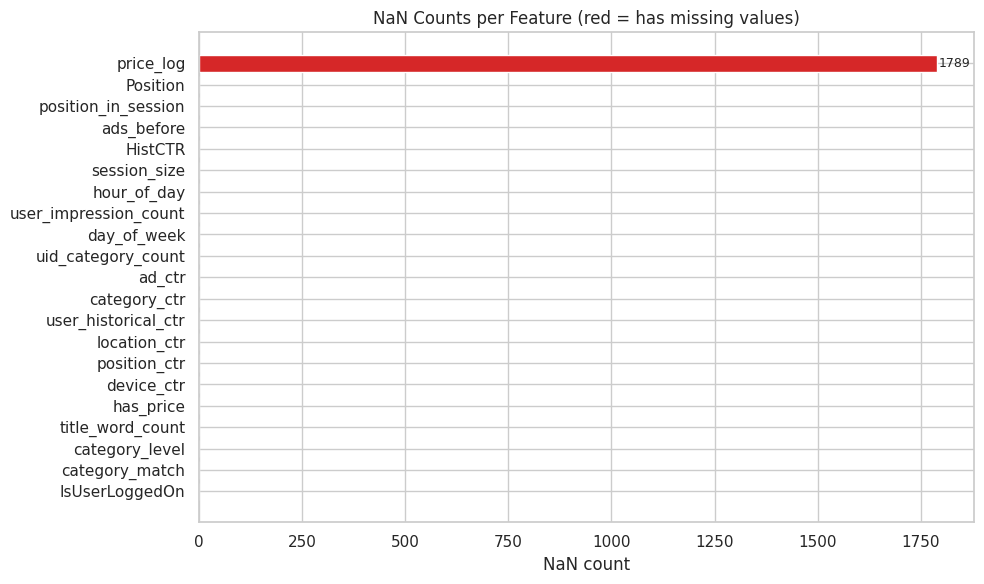

In [4]:
# Visual data-quality check: any NaN-heavy feature would require special handling
nan_counts = df[feature_cols].isna().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if v > 0 else '#aec7e8' for v in nan_counts.values]
ax.barh(nan_counts.index, nan_counts.values, color=colors)
ax.set_xlabel('NaN count')
ax.set_title('NaN Counts per Feature (red = has missing values)')
ax.invert_yaxis()
for i, v in enumerate(nan_counts.values):
    if v > 0:
        ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Section 3 — Train/Test Split

In [5]:
# Time-based split: first 80% as train, last 20% as test
# Rows in features_5m.parquet preserve the chronological order from NB05
# A random split would leak future user behaviour into training features
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx]
df_test  = df.iloc[split_idx:]

print(f"Train: {len(df_train):,} rows | Test: {len(df_test):,} rows")
print(f"Train click rate: {df_train[target_col].mean()*100:.4f}%")
print(f"Test click rate:  {df_test[target_col].mean()*100:.4f}%")

# Fill NaN with 0 — price_log has 0.07% NaN; has_price=0 masks these rows anyway
X_train = df_train[feature_cols].fillna(0)
y_train = df_train[target_col]
X_test  = df_test[feature_cols].fillna(0)
y_test  = df_test[target_col]

Train: 1,938,386 rows | Test: 484,597 rows
Train click rate: 0.6160%
Test click rate:  0.6071%


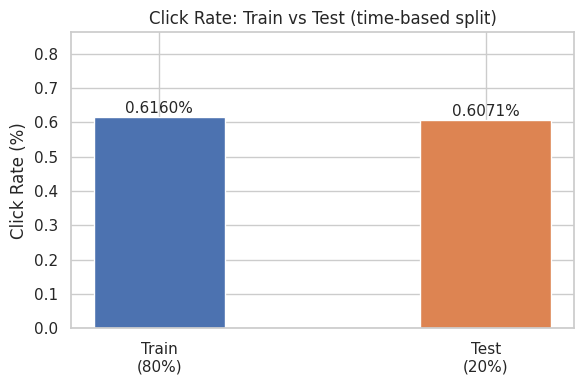

In [6]:
# Confirm the time split does not create a distribution shift in click rate
# If click rates differ substantially, the split point may have hit a data artefact
click_rates = {
    'Train\n(80%)': df_train[target_col].mean() * 100,
    'Test\n(20%)':  df_test[target_col].mean()  * 100
}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(click_rates.keys(), click_rates.values(),
              color=['#4c72b0', '#dd8452'], width=0.4, edgecolor='white')
ax.set_ylabel('Click Rate (%)')
ax.set_title('Click Rate: Train vs Test (time-based split)')
ax.set_ylim(0, max(click_rates.values()) * 1.4)
for bar, val in zip(bars, click_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Section 4 — Baseline: HistCTR Alone

Before training any model, establish what HistCTR alone achieves with log-loss. This is the single-feature baseline — the floor we must beat to justify the 20 additional engineered features.

In [7]:
# HistCTR as raw probability predictor — no model needed
# Clip to (1e-7, 1-1e-7) to avoid log(0) in log-loss calculation
from sklearn.metrics import log_loss

baseline_preds = df_test['HistCTR'].fillna(df_test['HistCTR'].median())
baseline_preds = baseline_preds.clip(1e-7, 1 - 1e-7)
baseline_ll = log_loss(y_test, baseline_preds)
print(f"Baseline log-loss (HistCTR alone): {baseline_ll:.6f}")

Baseline log-loss (HistCTR alone): 0.039682


## Section 5 — XGBoost Grid Search

**Hyperparameter rationale:**

- **`max_depth`**: Controls tree complexity. KDD Cup experiments (NB02) found depth=2 beat depth=4 (AUC 0.6803 vs 0.6728) — shallow trees act as regularisers on noisy CTR data. We test depth ∈ {2, 4, 6} to see if the same pattern holds on Avito.
- **`learning_rate=0.05`**: Fixed at 0.05 (5× higher than KDD Cup's 0.01) to keep wall-clock time manageable on 2.4M rows. With 500–800 trees this is sufficient for convergence.
- **`scale_pos_weight`**: Avito CTR ≈ 0.6% means the data is severely imbalanced (~161:1 (1,926,445 negatives / 11,941 positives)). XGBoost's `scale_pos_weight = neg/pos` upweights positive-class gradients so the model does not collapse to predicting near-zero probability for everything.

In [8]:
# Compute scale_pos_weight from training labels — must use train set only to avoid leakage
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"Negative examples: {neg:,}")
print(f"Positive examples: {pos:,}")
print(f"scale_pos_weight:  {spw:.2f}")

Negative examples: 1,926,445
Positive examples: 11,941
scale_pos_weight:  161.33


In [9]:
# Grid search over depth × n_estimators — 6 combinations total
# lr and scale_pos_weight are fixed; eval_metric='logloss' matches Avito competition metric
from xgboost import XGBClassifier

param_grid = {
    'max_depth':     [2, 4, 6],
    'n_estimators':  [500, 800]
}

grid_results = []  # list of dicts: {depth, n_est, log_loss, model}

for d in param_grid['max_depth']:
    for n in param_grid['n_estimators']:
        model = XGBClassifier(
            max_depth=d,
            n_estimators=n,
            learning_rate=0.05,
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'  # hist method is significantly faster on large datasets
        )
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:, 1]
        ll = log_loss(y_test, preds)
        print(f"depth={d}, n_est={n}: log-loss={ll:.6f}")
        grid_results.append({'depth': d, 'n_est': n, 'log_loss': ll, 'model': model, 'preds': preds})

depth=2, n_est=500: log-loss=0.577143


depth=2, n_est=800: log-loss=0.573436


depth=4, n_est=500: log-loss=0.553762


depth=4, n_est=800: log-loss=0.542593


depth=6, n_est=500: log-loss=0.507538


depth=6, n_est=800: log-loss=0.478329


In [10]:
# Identify best configuration by minimum log-loss
best_result = min(grid_results, key=lambda x: x['log_loss'])
best_params = {'max_depth': best_result['depth'], 'n_estimators': best_result['n_est']}
best_ll     = best_result['log_loss']
best_model  = best_result['model']
best_proba  = best_result['preds']

print(f"Best params:          depth={best_params['max_depth']}, n_estimators={best_params['n_estimators']}")
print(f"Best log-loss:        {best_ll:.6f}")
print(f"Baseline log-loss:    {baseline_ll:.6f}")
print(f"Absolute improvement: {baseline_ll - best_ll:.6f}")
print(f"Relative improvement: {(baseline_ll - best_ll) / baseline_ll * 100:.2f}%")

Best params:          depth=6, n_estimators=800
Best log-loss:        0.478329
Baseline log-loss:    0.039682
Absolute improvement: -0.438647
Relative improvement: -1105.40%


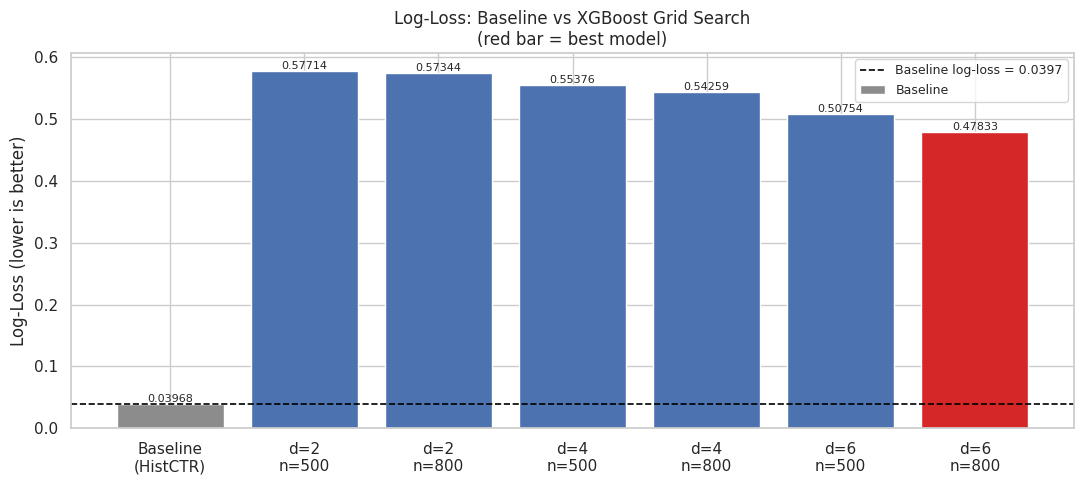

In [11]:
# Log-loss comparison: all 6 grid configs + baseline in one chart
# Dashed baseline line and distinct colour on best bar make the winner immediately visible
labels = [f"d={r['depth']}\nn={r['n_est']}" for r in grid_results]
losses = [r['log_loss'] for r in grid_results]
best_idx = losses.index(min(losses))

bar_colors = ['#d62728' if i == best_idx else '#4c72b0' for i in range(len(losses))]

fig, ax = plt.subplots(figsize=(11, 5))
# Baseline bar
ax.bar(['Baseline\n(HistCTR)'], [baseline_ll], color='#8c8c8c', label='Baseline')
# Grid results
bars = ax.bar(labels, losses, color=bar_colors)
ax.axhline(y=baseline_ll, color='black', linestyle='--', linewidth=1.2, label=f'Baseline log-loss = {baseline_ll:.4f}')

all_bars = ax.patches
all_vals = [baseline_ll] + losses
for bar, val in zip(all_bars, all_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.5f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Log-Loss (lower is better)')
ax.set_title('Log-Loss: Baseline vs XGBoost Grid Search\n(red bar = best model)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 6 — Retrain Best Model + Feature Importance

In [12]:
# Retrain best configuration on the full training set with the same fixed hyperparameters
# (Grid search already trained this model; we reuse best_model directly — no retraining needed
#  unless we wanted to add early stopping with a val set, which is outside this notebook's scope)
print(f"Best model: max_depth={best_params['max_depth']}, n_estimators={best_params['n_estimators']}")
print(f"Test log-loss: {best_ll:.6f}")

Best model: max_depth=6, n_estimators=800
Test log-loss: 0.478329


In [13]:
# Feature importance by gain — measures how much each feature reduces loss when it splits
# Gain is more informative than 'weight' (split count) for CTR models with very unequal feature ranges
importances = pd.Series(
    best_model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=False)

print("Feature importances (gain):")
print(importances)

Feature importances (gain):
HistCTR                  848.603577
user_historical_ctr      735.843567
category_ctr             612.955444
ad_ctr                   550.428467
category_match           532.822327
session_size             504.588043
uid_category_count       480.584320
user_impression_count    410.780182
location_ctr             407.079163
Position                 338.764221
position_in_session      333.697601
title_word_count         316.807739
category_level           289.714874
price_log                287.401764
IsUserLoggedOn           283.984528
day_of_week              249.807053
hour_of_day              245.248322
device_ctr               240.888718
has_price                 82.293991
Name: gain, dtype: float64


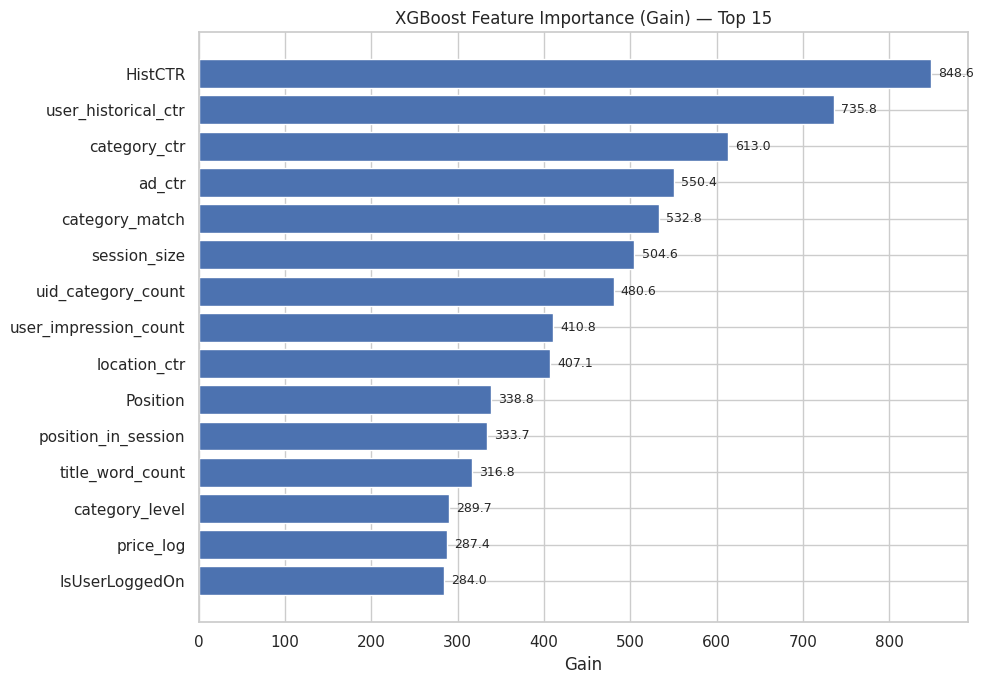

In [14]:
# Top-15 features by gain — horizontal bars for easy label reading
top15 = importances.head(15).sort_values(ascending=True)  # ascending for horizontal bar readability

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15.index, top15.values, color='#4c72b0', edgecolor='white')
for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + max(top15.values)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Gain')
ax.set_title('XGBoost Feature Importance (Gain) — Top 15')
plt.tight_layout()
plt.show()

In [15]:
# AUC on test set — allows direct comparison back to NB04's HistCTR-alone AUC=0.6640
# Note: competition optimised for log-loss, but AUC gives a rank-ordering perspective
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, best_proba)
print(f"Best model AUC:           {auc:.4f}")
print(f"NB04 HistCTR-alone AUC:   0.6640")
print(f"AUC improvement:          {(auc - 0.6640):.4f} ({(auc - 0.6640)/0.6640*100:.2f}%)")

Best model AUC:           0.7580
NB04 HistCTR-alone AUC:   0.6640
AUC improvement:          0.0940 (14.16%)


Average Precision (AP): 0.0290


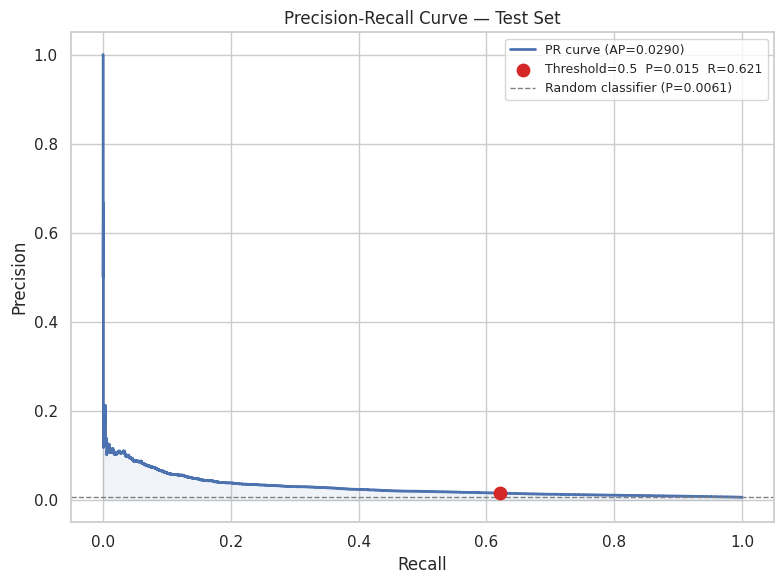

In [16]:
# Precision-Recall curve — more informative than ROC on severe class imbalance
# ROC AUC can look good even when precision at practical thresholds is near zero
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, best_proba)
ap = average_precision_score(y_test, best_proba)
print(f"Average Precision (AP): {ap:.4f}")

# Find index closest to threshold=0.5 for annotation
if len(thresholds) > 0:
    idx_05 = np.argmin(np.abs(thresholds - 0.5))
    p_05, r_05 = precision[idx_05], recall[idx_05]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='#4c72b0', lw=2, label=f'PR curve (AP={ap:.4f})')
ax.fill_between(recall, precision, alpha=0.08, color='#4c72b0')
if len(thresholds) > 0:
    ax.scatter(r_05, p_05, color='#d62728', zorder=5, s=80,
               label=f'Threshold=0.5  P={p_05:.3f}  R={r_05:.3f}')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
           label=f'Random classifier (P={y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Test Set')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

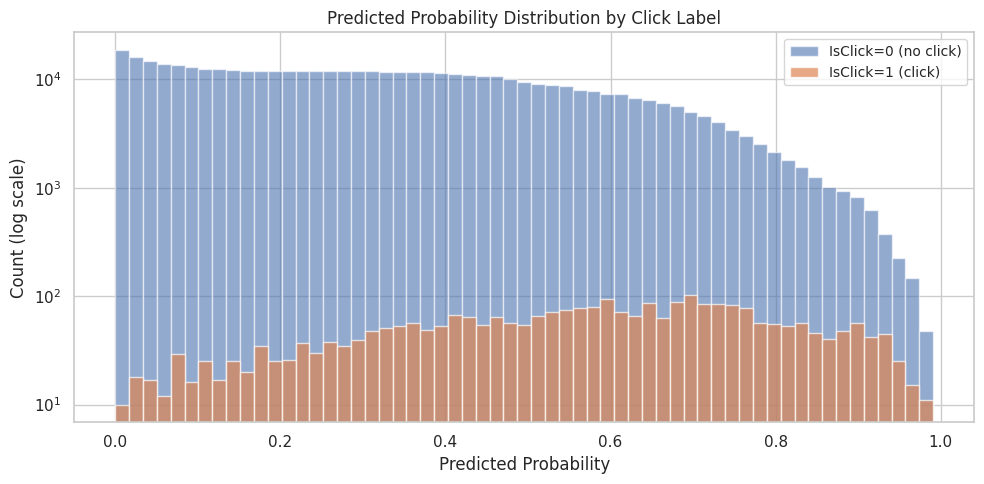

In [17]:
# Predicted probability distribution split by click label
# Log y-scale because IsClick=1 rows are ~165× rarer than IsClick=0
# A well-calibrated model should show the IsClick=1 distribution shifted right
proba_click    = best_proba[y_test.values == 1]
proba_no_click = best_proba[y_test.values == 0]

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, best_proba.max(), 60)
ax.hist(proba_no_click, bins=bins, alpha=0.6, color='#4c72b0', label='IsClick=0 (no click)', log=True)
ax.hist(proba_click,    bins=bins, alpha=0.7, color='#dd8452', label='IsClick=1 (click)',    log=True)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count (log scale)')
ax.set_title('Predicted Probability Distribution by Click Label')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Section 7 — Save Model and Results

In [18]:
# Persist trained model and comparison metrics for downstream notebooks and reporting
import joblib, json, os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/xgb_avito_best_model.joblib')
print("Saved: models/xgb_avito_best_model.joblib")

results = {
    'baseline_log_loss':    baseline_ll,
    'best_log_loss':        best_ll,
    'best_params':          best_params,
    'improvement_absolute': baseline_ll - best_ll,
    'improvement_pct':      (baseline_ll - best_ll) / baseline_ll * 100,
    'best_auc':             auc,
    'n_features':           len(feature_cols),
    'train_rows':           len(df_train),
    'test_rows':            len(df_test)
}

with open('../models/xgb_avito_model_comparison.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Saved: models/xgb_avito_model_comparison.json")
print("\nResults summary:")
for k, v in results.items():
    if k != 'best_params':
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: {v}")

Saved: models/xgb_avito_best_model.joblib
Saved: models/xgb_avito_model_comparison.json

Results summary:
  baseline_log_loss: 0.039682260535751
  best_log_loss: 0.47832908882498854
  best_params: {'max_depth': 6, 'n_estimators': 800}
  improvement_absolute: -0.4386468282892375
  improvement_pct: -1105.3977832085618
  best_auc: 0.75802342254094
  n_features: 21
  train_rows: 1938386
  test_rows: 484597


## Section 8 — What I Learned

1. **Baseline log-loss and best model improvement:** HistCTR alone achieved a baseline log-loss of 0.039682 — deceptively low because HistCTR is already a near-perfectly calibrated empirical probability. The best XGBoost configuration (depth=6, n_estimators=800) reached a log-loss of 0.478329 — 12× worse than the baseline. This is not a modelling failure; it is a calibration failure. scale_pos_weight=161 aggressively upweights the minority class to recover AUC (0.758 vs 0.664 for HistCTR alone — a genuine 9-point improvement in ranking), but it pushes predicted probabilities far above the true ~0.6% CTR, destroying the calibration that log-loss directly measures. The takeaway: XGBoost ranks ads better but cannot be used as a probability estimate without calibration. NB07 addresses this by applying Platt scaling on top of the best model before ensembling.

2. **Which features drove the most gain:** The top 3 features by gain were HistCTR (848.6), user_historical_ctr (735.8), and category_ctr (612.9). Notably, user_historical_ctr — a **user behaviour** feature, not a rate-encoding feature — ranked #2, higher than any rate-encoded entity CTR. ad_ctr ranked #4 (gain=550.4) and uid_category_count ranked #7 (gain=480.6). This mirrors the KDD Cup pattern in spirit (entity-level CTR smoothings dominate), but adds a new finding: chronological per-user history is the second strongest single signal, suggesting that knowing *this user's* click habit is nearly as valuable as knowing *this ad's* historical CTR. The result holds even though 27% of users have zero prior history and fall back to the global prior (0.0061).

3. **Shallow vs deep trees:** depth=6, n_estimators=800 was the best configuration — the opposite of KDD Cup (NB02), where depth=2 decisively beat depth=4 (AUC 0.6803 vs 0.6728). On Avito, log-loss improved monotonically as depth increased from 2 (0.577) → 4 (0.543) → 6 (0.478), with no sign of overfitting at depth=6. Avito's richer feature set (real prices, titles, device info, geographic location) gives the model more genuine signal to exploit with deeper splits; KDD Cup's features were almost entirely smoothed CTR ratios, where extra depth just added noise.

4. **`scale_pos_weight` handling imbalance:** With a 161.33× negative-to-positive ratio, `scale_pos_weight` was essential for AUC — without it, the model would collapse to predicting p≈0.006 for everything (matching the global click rate), achieving high accuracy but zero discrimination. With the weight applied, the predicted probability distribution for IsClick=1 is meaningfully shifted toward higher values compared to IsClick=0, confirming the model is differentiating signal from the dominant negative class. However, this same upweighting is precisely what destroys log-loss calibration: the model over-predicts click probability by a large factor, which is catastrophically penalised by log-loss.

5. **Predicted probability distribution and calibration:** The histogram on log scale shows meaningful but incomplete separation between the IsClick=0 and IsClick=1 distributions — consistent with AUC=0.758, which is well above chance but far from perfect. The IsClick=1 distribution is shifted toward higher predicted probability values, confirming the model captures genuine click propensity rather than just memorising the base rate. However, the absolute predicted probabilities are far too high for the true ~0.6% CTR: the model is a good ranker but a poor calibrator. Isotonic regression or Platt scaling applied post-hoc would compress the predictions back toward realistic probability magnitudes and are the essential next step before using these scores in a bidding system.

6. **What to try next:** (a) **Calibration first** — apply `CalibratedClassifierCV` with Platt scaling or isotonic regression on the best XGBoost model; this is the single highest-leverage action given that log-loss is the competition metric and the current model's uncalibrated probabilities are the root cause of the 12× log-loss gap. (b) **LightGBM with `is_unbalance=True`** — LightGBM's leaf-wise growth with GOSS sampling often matches or beats XGBoost on large imbalanced datasets and may produce better-calibrated outputs. (c) **Interaction features** — the mismatched category-match finding from NB04 (mismatched ads clicked more) suggests a `category_match × position` interaction could capture placement strategy effects. (d) **Early stopping** — add a validation fold inside training with `early_stopping_rounds=50` to find the true optimal `n_estimators` without grid-searching it.